In [ ]:
!pip3 install git+https://github.com/NetManAIOps/sktime.git
!pip3 install statsmodels

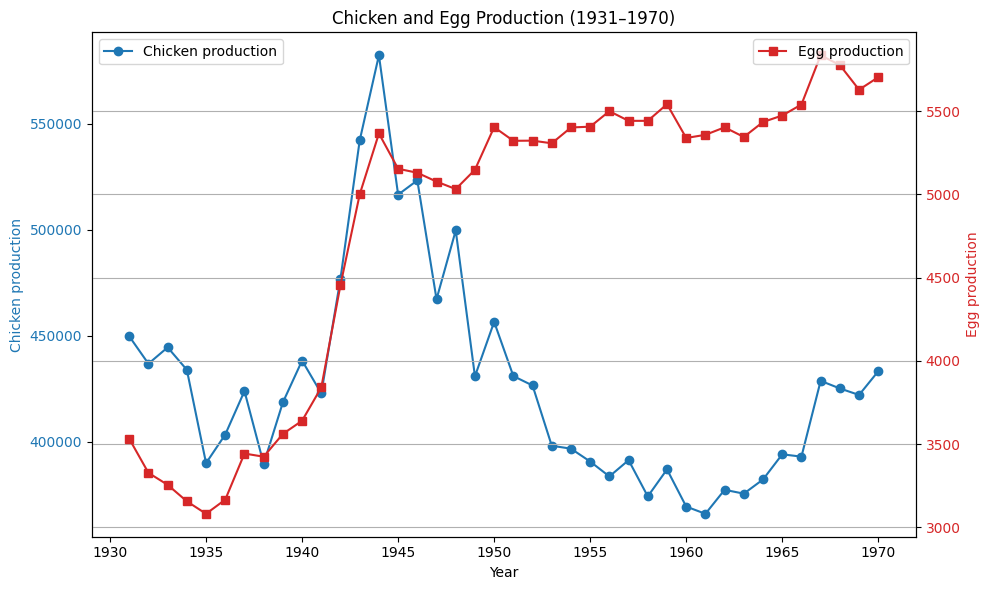

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sktime.distances import granger_distance
# ===================== Load Data =====================
data = {
    'year': list(range(1931, 1971)),
    'chicken': [
        449743,436815,444523,433937,389958,403446,423921,389624,418591,438288,
        422841,476935,542047,582197,516497,523227,467217,499644,430876,456549,
        430988,426555,398156,396776,390708,383690,391363,374281,387002,369484,
        366082,377392,375575,382262,394118,393019,428746,425158,422096,433280
    ],
    'egg': [
        3532,3327,3255,3156,3081,3166,3443,3424,3561,3640,
        3840,4456,5000,5366,5154,5130,5077,5032,5148,5404,
        5322,5323,5307,5402,5407,5500,5442,5442,5542,5339,
        5358,5403,5345,5435,5474,5540,5836,5777,5629,5704
    ]
}

df = pd.DataFrame(data)

# ===================== Visualization (Two Y-axes) =====================
fig, ax1 = plt.subplots(figsize=(10, 6))

# Chicken production - on left Y-axis
ax1.plot(df['year'], df['chicken'], color='tab:blue', marker='o', label='Chicken production')
ax1.set_xlabel('Year')
ax1.set_ylabel('Chicken production', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
plt.legend(loc='upper left')
# Egg production - on right Y-axis
ax2 = ax1.twinx()
ax2.plot(df['year'], df['egg'], color='tab:red', marker='s', label='Egg production')
ax2.set_ylabel('Egg production', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Chicken and Egg Production (1931–1970)')
plt.legend(loc='upper right')
fig.tight_layout()
plt.grid(True)
plt.show()


In [ ]:
# ===================== Granger Distance =====================
chicken = df['chicken'].values
egg = df['egg'].values
max_lag = 12
gra_dist = granger_distance(chicken, egg, max_lag=max_lag)
print(f"granger_distance(chicken, egg, max_lag={max_lag}) = {gra_dist:.4f}")

granger_distance(chicken, egg, max_lag=12) = 0.9991


/Users/wannabtl/Documents/code/.venv/lib/python3.14/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/wannabtl/Documents/code/.venv/lib/python3.14/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sktime.distances import granger_distance

# ===================== Load Data =====================
data = {
    'year': list(range(1931, 1971)),
    'chicken': [
        449743,436815,444523,433937,389958,403446,423921,389624,418591,438288,
        422841,476935,542047,582197,516497,523227,467217,499644,430876,456549,
        430988,426555,398156,396776,390708,383690,391363,374281,387002,369484,
        366082,377392,375575,382262,394118,393019,428746,425158,422096,433280
    ],
    'egg': [
        3532,3327,3255,3156,3081,3166,3443,3424,3561,3640,
        3840,4456,5000,5366,5154,5130,5077,5032,5148,5404,
        5322,5323,5307,5402,5407,5500,5442,5442,5542,5339,
        5358,5403,5345,5435,5474,5540,5836,5777,5629,5704
    ]
}

df = pd.DataFrame(data)

# ===================== First Difference =====================
df_diff = df.copy()
df_diff['chicken'] = df_diff['chicken'].diff()
df_diff['egg'] = df_diff['egg'].diff()

df_diff = df_diff.dropna().reset_index(drop=True)

# ===================== Visualization (Two Y-axes) =====================
fig, ax1 = plt.subplots(figsize=(10, 6))

# Chicken production diff - left Y-axis
ax1.plot(df_diff['year'], df_diff['chicken'], color='tab:blue', marker='o', label='Δ Chicken production')
ax1.set_xlabel('Year')
ax1.set_ylabel('Δ Chicken production', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Egg production diff - right Y-axis
ax2 = ax1.twinx()
ax2.plot(df_diff['year'], df_diff['egg'], color='tab:red', marker='s', label='Δ Egg production')
ax2.set_ylabel('Δ Egg production', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.title('First Difference of Chicken and Egg Production (1932–1970)')
fig.tight_layout()
plt.grid(True)
plt.show()


In [ ]:
df = pd.DataFrame(data)
df_diff = df[['chicken', 'egg']].diff().dropna()

from statsmodels.tsa.stattools import grangercausalitytests

print("egg -> chicken")
grangercausalitytests(df_diff[['chicken', 'egg']], maxlag=4)

print("chicken -> egg")
grangercausalitytests(df_diff[['egg', 'chicken']], maxlag=4)